3 capas de 128,64,32 

In [1]:
# librerias
import numpy as np

# TensorFlow y Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Matplotlib
import matplotlib.pyplot as plt

In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [3]:
print("x_train:", x_train.shape)
print("y_train:", y_train.shape)
print("x_test:", x_test.shape)
print("y_test:", y_test.shape)

x_train: (60000, 28, 28)
y_train: (60000,)
x_test: (10000, 28, 28)
y_test: (10000,)


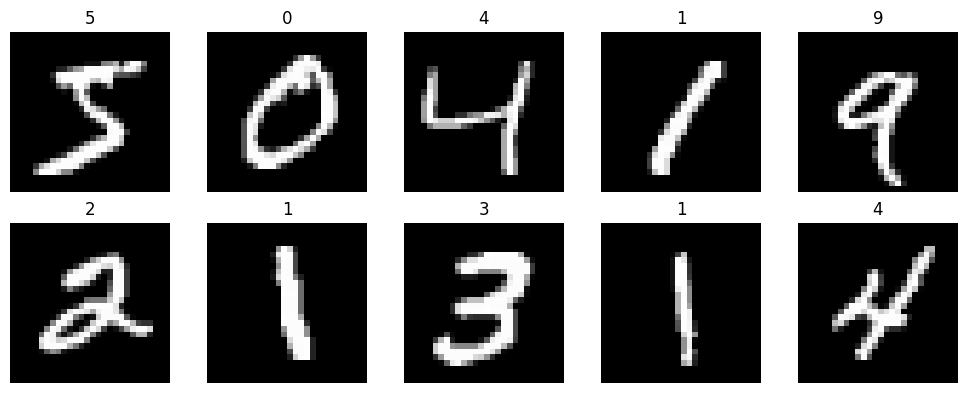

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"{y_train[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [5]:
print(x_train[0])

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136
  175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253
  225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251
   93  82  82  56  39   0   0   0   0   0]
 [  0   0   0   0   0   0   0  18 219 253 253 253 253 253 198 18

In [8]:
# Convertir a float y normalizar
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0


print("Valor mínimo x_train:", x_train.min())
print("Valor máximo x_train:", x_train.max())

Valor mínimo x_train: 0.0
Valor máximo x_train: 1.5378702e-05


In [9]:
from tensorflow.keras.optimizers import Adam

optimizer = Adam(learning_rate=0.1)

In [10]:
from tensorflow import keras
from tensorflow.keras import layers

mi_modelo = keras.Sequential([
    layers.Input(shape=(28, 28)),   # Entrada 28x28
    layers.Flatten(),               # Aplanar imagen
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(10)
])

In [11]:
from tensorflow.keras import losses

perdida = losses.SparseCategoricalCrossentropy(from_logits=True)

In [12]:
mi_modelo.compile(
    optimizer=optimizer,
    loss=perdida,
    metrics=['accuracy']
)

In [13]:
history = mi_modelo.fit(
    x_train, 
    y_train, 
    epochs=7, 
    validation_data=(x_test, y_test)
)

Epoch 1/7
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.1047 - loss: 2.3147 - val_accuracy: 0.1010 - val_loss: 2.3124
Epoch 2/7
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 971us/step - accuracy: 0.1035 - loss: 2.3154 - val_accuracy: 0.0980 - val_loss: 2.3109
Epoch 3/7
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.1020 - loss: 2.3140 - val_accuracy: 0.0982 - val_loss: 2.3285
Epoch 4/7
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 971us/step - accuracy: 0.1026 - loss: 2.3143 - val_accuracy: 0.1135 - val_loss: 2.3100
Epoch 5/7
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.1017 - loss: 2.3140 - val_accuracy: 0.1028 - val_loss: 2.3067
Epoch 6/7
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 972us/step - accuracy: 0.1028 - loss: 2.3145 - val_accuracy: 0.1135 - val_loss: 2.3094
Epoch 7/7
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 977us/step - accuracy: 0.1014 - loss: 2.3142 - val_accuracy: 0.1009 - val_loss: 2.3084


In [14]:
mi_modelo.evaluate(x_test, y_test, verbose=2)

313/313 - 0s - 611us/step - accuracy: 0.1009 - loss: 2.3084


[2.308366537094116, 0.10090000182390213]

In [15]:
mi_modelo.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 333,440 (1.27 MB)

 Trainable params: 111,146 (434.16 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 222,294 (868.34 KB)